# *Heart Failure* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

The [*Heart Failure* dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) belongs to the area of health and medicine, containing medical records of heart failure patients.

For details about the dataset, the *UCI* webpage points to
- Davide Chicco, Giuseppe Jurman (2020) *Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone*. BMC Medical Informatics and Decision Making 20(16). https://doi.org/10.1186/s12911-020-1023-5

which points further to the [dataset provided as supplementary material](https://plos.figshare.com/articles/Survival_analysis_of_heart_failure_patients_A_case_study/5227684/1) in
- Tanvir Ahmad, Assia Munir, Sajjad Haider Bhatti , Muhammad Aftab, Muhammad Ali Raza (2017) *Survival analysis of heart failure patients: a case study*. PloS one, 12(7):0181001 https://doi.org/10.1371/journal.pone.0181001


The 299 individuals whose information is included in the dataset were patients admitted at the *Institute of Cardiology* or the *Allied Hospital* in Faisalabad (Punjab, Pakistan), between April and December 2015.
The 105 women and 194 men, aged 40 years or above, had left ventricular systolic dysfunction and were put in classes III or IV, the two most serious classes, of the [*New York Heart Association (NYHA)* Functional Classification](https://en.wikipedia.org/wiki/New_York_Heart_Association_Functional_Classification), which classifies the extent of heart failure.

The dataset contains thirteen attributes, including clinical, physiological and lifestyle information. In particular, one attribute, denoted as `DEATH_EVENT`, records whether the patient died during the follow-up period. This attribute is typically used as classification target.

We load the data from the file.

In [2]:
heartfail_path = "./heart+failure+clinical+records/heart_failure_clinical_records_dataset.csv"
heartfail_dtf = pandas.read_csv(heartfail_path, sep=",")
heartfail_targetname = "DEATH_EVENT"

We write a function to list the columns that have missing values in a given dataset, or report that there are none, and we apply it to the dataset we just loaded.

In [3]:
def check_missing_values(dtf):
    cols_missing_values = [c for c in dtf if dtf[c].isna().any()]
    if len(cols_missing_values) > 0:
        print("\n\t- ".join(
            ["The following %s columns contain missing values:" % len(cols_missing_values)]+
            cols_missing_values))
    else:
        print("No values are missing.")

check_missing_values(heartfail_dtf)

No values are missing.


We show an outline of the dataset.

In [4]:
heartfail_dtf

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


As expected, the dataset contains 299 rows and 13 columns. The columns consist of a mix of numerical and binary attributes.

We select the numerical attributes, keeping only the columns that take strictly more than two distinct values, and show descriptive statistics.

For each of the numerical attributes, the summary includes the number of values (`count`, which is equal to the number of patients since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

In [5]:
num_columns = [d for d in heartfail_dtf.columns if len(pandas.unique(heartfail_dtf[d])) > 2]
heartfail_dtf[num_columns].describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
count,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208
min,40.000000,23.000000,14.000000,25100.000000,0.50000,113.000000,4.000000
25%,51.000000,116.500000,30.000000,212500.000000,0.90000,134.000000,73.000000
50%,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
75%,70.000000,582.000000,45.000000,303500.000000,1.40000,140.000000,203.000000
max,95.000000,7861.000000,80.000000,850000.000000,9.40000,148.000000,285.000000


We see that all patients are indeed aged 40 years or above, with both the mean and the median roughly equal to 50, while the oldest patient included in this dataset is 95 years old.

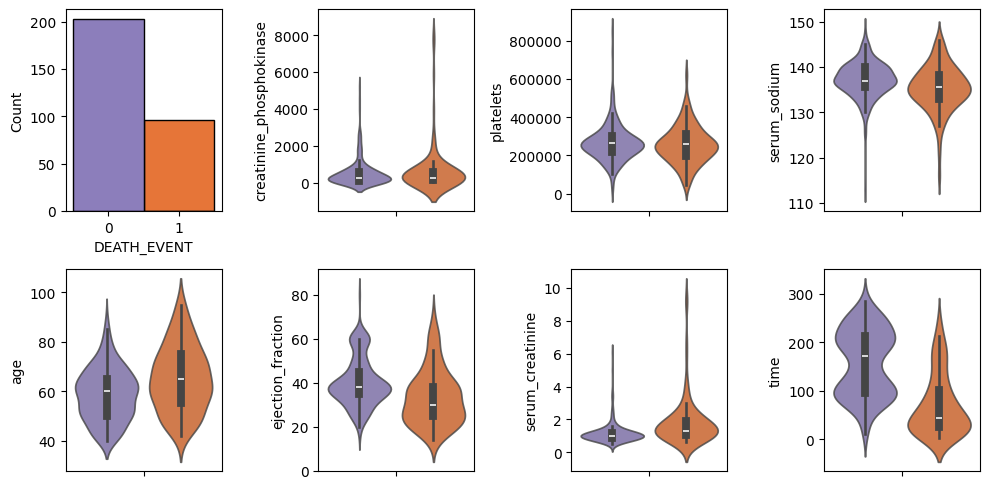

In [6]:
heartfail_colors = {0: "Purples", 1: "Oranges"}
heartfail_palette = seaborn.color_palette([seaborn.color_palette(heartfail_colors[0])[-2],
                                           seaborn.color_palette(heartfail_colors[1])[-2]])

f, axes = plt.subplots(2, (len(num_columns)+1)//2)
seaborn.histplot(data=heartfail_dtf, x=heartfail_targetname, hue=heartfail_targetname,
                 palette=heartfail_palette, discrete=True,
                 alpha=0.8, ax=axes[0, 0], legend=False)
for ci, c in enumerate(num_columns):
    seaborn.violinplot(heartfail_dtf, y=c, hue=heartfail_targetname,
                    ax=axes[(ci+1)%2, (ci+1)//2], width=0.95, dodge=True, gap=0.15,
                    palette=heartfail_palette, alpha=0.8, legend=False)
f.tight_layout()

About one third of the patients died during the follow-up period and two-third survived (`Count` histogram in the top, left-most panel). Overall, the patients who died seem to be slightly older (`age`), have lower ejection fraction (`ejection_fraction`), as well as somewhat lower serum sodium (`serum_sodium`) but higher serum creatinine (`serum creatinine`) values.

The follow-up time (`time`) is on average longer for patient who survived, which seems logical, since the death of a patient during the follow-up period causes it to end early.

Note that it would not make sense to use the follow-up time as predictive attribute when trying to predict whether patients survive.

Next, we focus on the six binary attributes, namely `DEATH_EVENT`, `sex`, `anaemia`, `high_blood_pressure` `diabetes` and `smoking`.

We count the number of times each of the $2^6=64$ different combinations of values for these attributes appears in the dataset, using our custom function `count_binary_values`.
We display these counts using heatmaps, considering separately patients who survived (purple, left-hand side) from patients who died (orange, right-hand side), and men (bottom) from women (top). The intensity of color of each cell is determined based on the fraction of patients from the considered subgroup that the cell represents within the corresponding population. The colormaps are scaled to the same range, to make the plots more easily comparable across the four different populations.

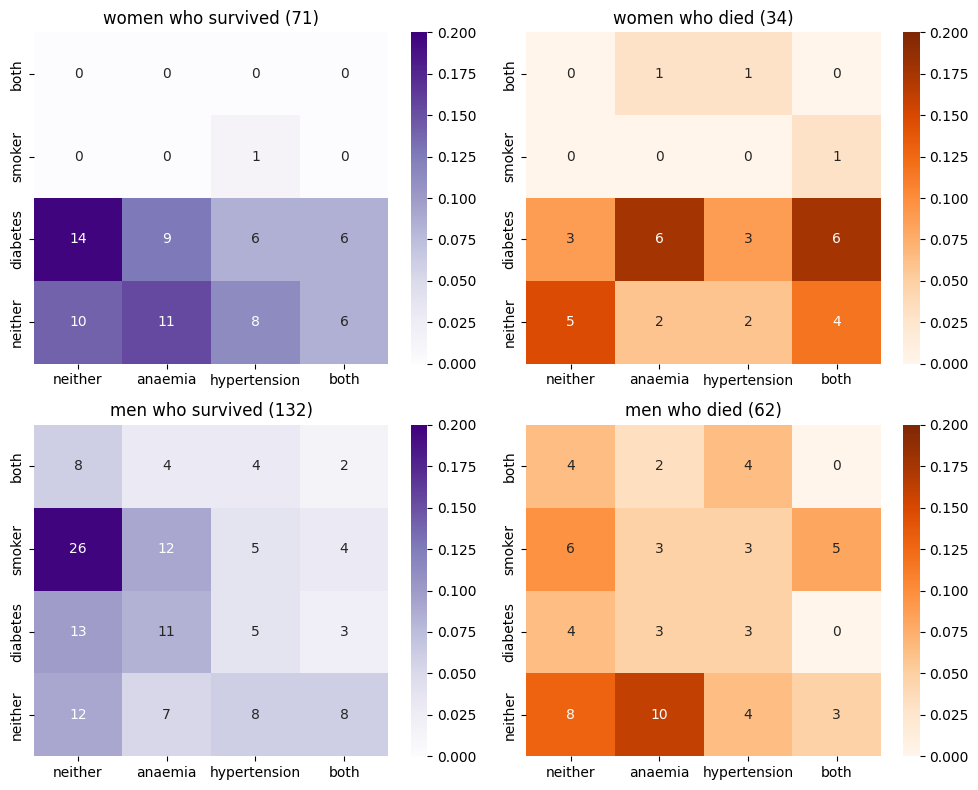

In [7]:
import itertools

def count_binary_values(dtf, binary_columns):
    cc = dtf.groupby(binary_columns).size()
    map_counts = dict([(k, 0) for k in itertools.product([0,1], repeat=len(binary_columns))])
    for i,v in enumerate(cc.values):
        map_counts[cc.index.values[i]] = v
    counts_array = numpy.array([k+(v,) for k,v in map_counts.items()])
    return pandas.DataFrame(counts_array, columns=cc.index.names + ["counts"])


heat_columns = ["high_blood_pressure", "anaemia"]
heat_column_labels = ["neither", "anaemia", "hypertension", "both"]
heat_rows = ["smoking", "diabetes"]
heat_row_labels = ["both", "smoker", "diabetes", "neither"]
varA = heartfail_targetname
varB = "sex"

counts_dtf = count_binary_values(heartfail_dtf, [varA, varB]+heat_columns+heat_rows)

subgroups = []
for valB in [0, 1]:
    for valA in [0, 1]:
        sub_counts = counts_dtf.loc[(counts_dtf[varA]==valA) & (counts_dtf[varB]==valB)]
        total = sub_counts["counts"].sum()
        counts_mat = sub_counts.pivot(index=heat_rows, columns=heat_columns, values="counts")\
            .sort_index(axis=0, ascending=False).sort_index(axis=1)
        subgroups.append({"valA": valA, "valB": valB,
                          "counts_mat": counts_mat,
                         "total": total,
                         "max_ratio": sub_counts["counts"].max()/total})

max_ratio = numpy.ceil(10*numpy.max([subg["max_ratio"] for subg in subgroups]))/10

f, axes = plt.subplots(2, 2)
for ci, subg in enumerate(subgroups):
    # heat_mat = 100*heat_mat
    seaborn.heatmap(subg["counts_mat"]/subg["total"], annot=subg["counts_mat"], fmt=".0f",
                    cmap=heartfail_colors[subg["valA"]], ax=axes[ci//2, ci%2], vmin=0, vmax=max_ratio)
    axes[ci//2, ci%2].set(xlabel="", ylabel="")
    axes[ci//2, ci%2].set_xticklabels(heat_column_labels)
    axes[ci//2, ci%2].set_yticklabels(heat_row_labels)
    axes[ci//2, ci%2].set_title("%s who %s (%d)" % ("women" if subg["valB"] == 0 else "men",
        "survived" if subg["valA"] == 0 else "died", subg["total"]))

f.set_figheight(8)
f.tight_layout()

We note that almost no female patients are smokers, as visible from the very low counts in the first two rows in the upper-most plots, whereas a large fraction of male patients smoke.

Many female patients who died had both diabetes and anaemia as well as possibly hypertension (6 patients each, dark brown cells in the top-right panel), whereas the conditions tend to be observed somewhat more often separately than in combination in female patients who survived.

No clear pattern of association between the conditions is visible.

Finally, we plot the distribution of age separately for patients who survived (purple) and patients who died (orange), further splitting successively by sex, smoking status, diabetes and hypertension.

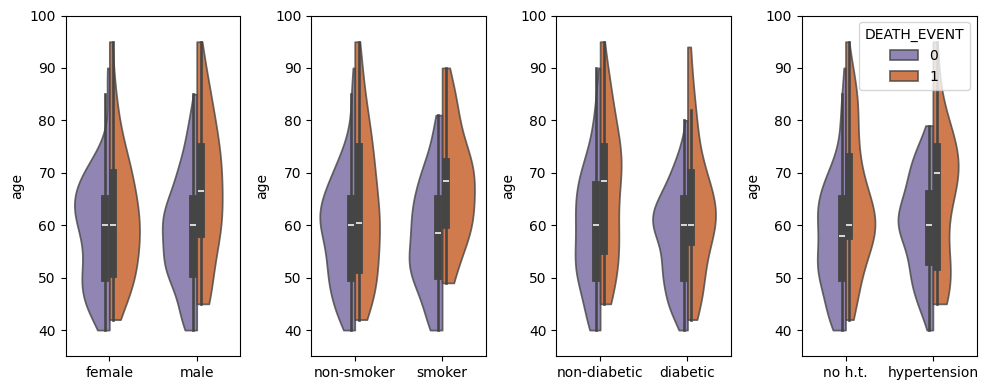

In [8]:
varsX = [("sex", ["female", "male"]), ("smoking", ["non-smoker", "smoker"]),
         ("diabetes", ["non-diabetic", "diabetic"]),("high_blood_pressure", ["no h.t.", "hypertension"])]

f, axes = plt.subplots(1, len(varsX))
for ci, (varX, lblsX) in enumerate(varsX):
    seaborn.violinplot(
        data=heartfail_dtf, x=varX, y="age", hue=heartfail_targetname, palette=heartfail_palette,
        alpha=0.8, cut=0, split=True, common_norm=True, ax=axes[ci], legend=ci==len(varsX)-1)
    axes[ci].set_xticks([0,1],lblsX)
    axes[ci].set_xlabel("")
    axes[ci].set_ylim(35,100)

f.set_figheight(4)
f.tight_layout()

While female patients in both outcome groups have the same median age, the median age of male patients who survived is about five years lower than the median age of male patients who died. Similarly, the median age of non-smoking patients is similar across both outcome groups, but the median age of smokers who survived is about ten years lower than that of smoking patients who died. On the other hand, the median age is similar for both outcome groups of diabetic patients, but almost ten years higher for non-diabetic patients who died than for non-diabetic patients who survived.